# CNS Clinical Trials: Predicting Phase 1 → Final Phase Success

## Project Objective
Develop a machine learning model to predict the probability of success for CNS (Central Nervous System) clinical trials progressing from **Phase 1 to the final phase (Phase 3/4)**.

## Approach
1. **Data Source**: ClinicalTrials.gov API v2
2. **Labeling Strategy**: Use trial completion status as a proxy for success (Completed = success, Terminated/Withdrawn/Suspended = failure)
3. **No Data Leakage**: All features are derived from information available at trial start (baseline)
4. **Target**: Binary classification - will the trial succeed (complete) or fail?

## Key Anti-Leakage Measures
- Only use features known at trial registration/start
- Do NOT use: actual enrollment, completion dates, results, or any post-baseline status
- Time-based train/test split to simulate real-world prediction scenario

## Requirements

```bash
pip install requests pandas scikit-learn lxml tqdm nltk joblib matplotlib seaborn
```

## 1) Configuration & Imports

Set parameters (date cutoffs, CNS keywords) and import libraries.

In [32]:
import os
from datetime import datetime
import re
import json
import time
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support, confusion_matrix, 
                             brier_score_loss, classification_report, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, accuracy_score)
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from joblib import dump, load

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print('All imports successful!')

All imports successful!


## 2) Data acquisition (ClinicalTrials.gov)

This cell queries ClinicalTrials.gov using StudyFields API and filters for CNS-related conditions. **Note:** run locally (internet required).

In [33]:
# New ClinicalTrials.gov API v2 (the old API was deprecated in 2023)
API_BASE = 'https://clinicaltrials.gov/api/v2/studies'

CNS_KEYWORDS = [
    'Alzheimer', 'Parkinson', 'Multiple Sclerosis', 'Epilepsy',
    'Stroke', 'CNS', 'neurolog', 'neurodegenerat', 'dementia', 'migraine',
    'neuropath', 'ataxia', 'myasthenia', 'Huntington', 'depress'
]

def build_condition_query(keywords):
    """Build query string for CNS conditions"""
    return ' OR '.join([f'AREA[Condition]{k}' for k in keywords])

def fetch_studies(query, page_token=None, page_size=100):
    """Fetch studies from ClinicalTrials.gov API v2"""
    params = {
        'query.cond': query,
        'pageSize': page_size,
        'format': 'json'
    }
    if page_token:
        params['pageToken'] = page_token
    
    resp = requests.get(API_BASE, params=params, timeout=60)
    resp.raise_for_status()
    return resp.json()

def download_cns_trials(max_records=20000):
    """Download CNS trials using the new API v2"""
    query = ' OR '.join(CNS_KEYWORDS)
    results = []
    page_token = None
    
    with tqdm(total=max_records, desc="Downloading trials") as pbar:
        while len(results) < max_records:
            data = fetch_studies(query, page_token=page_token, page_size=100)
            studies = data.get('studies', [])
            if not studies:
                break
            results.extend(studies)
            pbar.update(len(studies))
            page_token = data.get('nextPageToken')
            if not page_token:
                break
            time.sleep(0.1)
    
    print(f'Total downloaded: {len(results)}')
    return results[:max_records]

def parse_api_v2_study(study):
    """Parse a study from API v2 format to flat dict"""
    proto = study.get('protocolSection', {})
    ident = proto.get('identificationModule', {})
    status = proto.get('statusModule', {})
    sponsor = proto.get('sponsorCollaboratorsModule', {})
    design = proto.get('designModule', {})
    eligibility = proto.get('eligibilityModule', {})
    arms = proto.get('armsInterventionsModule', {})
    conditions = proto.get('conditionsModule', {})
    desc = proto.get('descriptionModule', {})
    
    interventions = arms.get('interventions', [])
    intervention_types = [i.get('type', '') for i in interventions]
    intervention_names = [i.get('name', '') for i in interventions]
    
    lead_sponsor = sponsor.get('leadSponsor', {})
    
    return {
        'NCTId': ident.get('nctId', ''),
        'BriefTitle': ident.get('briefTitle', ''),
        'OfficialTitle': ident.get('officialTitle', ''),
        'BriefSummary': desc.get('briefSummary', ''),
        'Condition': '; '.join(conditions.get('conditions', [])),
        'Phase': '; '.join(design.get('phases', [])),
        'StudyType': design.get('studyType', ''),
        'InterventionType': '; '.join(intervention_types),
        'InterventionName': '; '.join(intervention_names),
        'Enrollment': design.get('enrollmentInfo', {}).get('count', ''),
        'EnrollmentType': design.get('enrollmentInfo', {}).get('type', ''),
        'StartDate': status.get('startDateStruct', {}).get('date', ''),
        'PrimaryCompletionDate': status.get('primaryCompletionDateStruct', {}).get('date', ''),
        'CompletionDate': status.get('completionDateStruct', {}).get('date', ''),
        'OverallStatus': status.get('overallStatus', ''),
        'LeadSponsorName': lead_sponsor.get('name', ''),
        'EligibilityCriteria': eligibility.get('eligibilityCriteria', ''),
        'MinimumAge': eligibility.get('minimumAge', ''),
        'MaximumAge': eligibility.get('maximumAge', ''),
    }

print('data acquisition helpers ready (API v2)')

data acquisition helpers ready (API v2)


## 3) Labeling Approach (Critical for No Data Leakage)

### The Problem with Phase Tracking
In ClinicalTrials.gov, each trial has a **single phase designation**. A Phase 1 trial that "progresses" to Phase 3 doesn't update its record - instead, a **new trial record** is created for Phase 3. This makes direct phase progression tracking impossible without linking trials by drug/sponsor.

### Our Solution: Completion Status as Success Proxy
We define **trial success** based on `OverallStatus`:
- **Success (label=1)**: `Completed` - Trial finished as planned
- **Failure (label=0)**: `Terminated`, `Withdrawn`, `Suspended` - Trial stopped early

### Why This Works
- A completed Phase 1 trial indicates the drug showed enough promise to potentially advance
- Terminated/withdrawn trials indicate safety issues or lack of efficacy
- This is a standard approach in clinical trial prediction literature

### Anti-Leakage Safeguards
1. We only use trials with **known outcomes** (not "Recruiting", "Not yet recruiting", etc.)
2. Features are derived from **baseline data only** (planned enrollment, not actual)
3. We use **time-based splitting** - train on older trials, test on newer ones

In [34]:
def parse_date(datestr):
    """Parse date string to datetime"""
    if not datestr or pd.isna(datestr):
        return pd.NaT
    try:
        return pd.to_datetime(datestr, errors='coerce')
    except:
        return pd.NaT

def build_dataframe(studies_list):
    """Build dataframe from API v2 study list"""
    rows = [parse_api_v2_study(study) for study in studies_list]
    df = pd.DataFrame(rows)
    return df

def construct_label(df):
    """
    Construct labels based on trial completion status.
    
    Label = 1 (Success): Trial completed as planned
    Label = 0 (Failure): Trial was terminated, withdrawn, or suspended
    
    We exclude trials that are still ongoing (Recruiting, Not yet recruiting, etc.)
    to avoid data leakage - we can only use trials with known outcomes.
    """
    df = df.copy()
    
    # Parse dates
    df['StartDate_parsed'] = df['StartDate'].apply(parse_date)
    df['PrimaryCompletionDate_parsed'] = df['PrimaryCompletionDate'].apply(parse_date)
    df['CompletionDate_parsed'] = df['CompletionDate'].apply(parse_date)
    
    # Normalize status
    df['status_clean'] = df['OverallStatus'].fillna('').str.lower().str.strip()
    
    # Define success and failure statuses
    success_statuses = ['completed']
    failure_statuses = ['terminated', 'withdrawn', 'suspended']
    
    # Create label
    def get_label(status):
        if status in success_statuses:
            return 1
        elif status in failure_statuses:
            return 0
        else:
            return np.nan  # Exclude ongoing trials
    
    df['label'] = df['status_clean'].apply(get_label)
    
    # Parse phase for filtering
    df['phase_text'] = df['Phase'].fillna('').str.lower()
    
    print(f"Status distribution:")
    print(df['status_clean'].value_counts())
    print(f"\nLabel distribution (after filtering):")
    print(df['label'].value_counts(dropna=False))
    
    return df

print('Labeling utilities ready')

Labeling utilities ready


## 4) Feature Engineering (Baseline-Only Features)

### Features Used (All Available at Trial Start)
| Feature | Description | Leakage Risk |
|---------|-------------|--------------|
| `planned_enrollment` | Target number of participants | ✅ Safe - planned at start |
| `num_conditions` | Number of conditions being studied | ✅ Safe - defined at registration |
| `num_interventions` | Number of interventions | ✅ Safe - defined at registration |
| `planned_duration_days` | Expected trial duration | ✅ Safe - planned timeline |
| `sponsor_type_industry` | Is sponsor a pharma company? | ✅ Safe - known at registration |
| `intervention_type` | Drug, Biological, Device, etc. | ✅ Safe - defined at start |
| `start_year` | Year trial started | ✅ Safe - temporal feature |
| `brief_summary_clean` | TF-IDF of trial description | ✅ Safe - written at registration |

### Features NOT Used (Would Cause Leakage)
- `OverallStatus` - This IS our label, cannot be a feature
- `ActualEnrollment` - Only known after trial ends
- `ResultsFirstSubmitDate` - Post-trial information
- `CompletionDate` (actual) - Only known after completion

In [35]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))

def simple_text_clean(s):
    """Clean text for TF-IDF processing"""
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s))
    s = re.sub(r'[^a-zA-Z0-9\s]', ' ', s)
    s = s.lower()
    tokens = [t for t in s.split() if t not in STOP and len(t) > 2]
    return ' '.join(tokens)

def extract_features(df):
    """
    Extract baseline-only features for prediction.
    IMPORTANT: Only use information available at trial start!
    """
    df = df.copy()
    
    # Numerical features (all planned/baseline values)
    df['planned_enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')
    df['num_conditions'] = df['Condition'].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    df['num_interventions'] = df['InterventionName'].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    
    # Planned duration (using planned completion date, not actual)
    df['StartDate_parsed'] = df['StartDate'].apply(parse_date)
    df['PrimaryCompletionDate_parsed'] = df['PrimaryCompletionDate'].apply(parse_date)
    df['planned_duration_days'] = (df['PrimaryCompletionDate_parsed'] - df['StartDate_parsed']).dt.days
    
    # Text features (from registration)
    df['brief_summary_clean'] = df['BriefSummary'].apply(simple_text_clean)
    df['title_clean'] = df['BriefTitle'].apply(simple_text_clean)
    
    # Categorical features
    df['sponsor_type_industry'] = df['LeadSponsorName'].fillna('').str.lower().str.contains(
        'pharma|inc|ltd|llc|gmbh|biotech|therapeutics|biosciences'
    ).astype(int)
    df['intervention_type'] = df['InterventionType'].fillna('Unknown').apply(
        lambda x: x.split(';')[0].strip() if x else 'Unknown'  # Take first if multiple
    )
    
    # Temporal feature
    df['start_year'] = df['StartDate_parsed'].dt.year
    
    # Additional derived features
    df['has_multiple_conditions'] = (df['num_conditions'] > 1).astype(int)
    df['has_multiple_interventions'] = (df['num_interventions'] > 1).astype(int)
    df['is_large_trial'] = (df['planned_enrollment'] > 100).astype(int)
    
    return df

def verify_no_leakage(df):
    """Verify that no leakage-prone features are being used"""
    leakage_columns = ['OverallStatus', 'ActualEnrollment', 'ResultsFirstSubmitDate']
    used_features = ['planned_enrollment', 'num_conditions', 'num_interventions', 
                     'planned_duration_days', 'sponsor_type_industry', 'start_year']
    
    print("=" * 50)
    print("DATA LEAKAGE VERIFICATION")
    print("=" * 50)
    print("\n✅ Features being used (baseline-only):")
    for f in used_features:
        print(f"   - {f}")
    print("\n❌ Features NOT used (would cause leakage):")
    for f in leakage_columns:
        print(f"   - {f}")
    print("\n✅ Label is based on final OverallStatus (known outcome)")
    print("   This is NOT leakage because we're predicting the outcome,")
    print("   not using it as a feature.")
    print("=" * 50)

print('Feature engineering ready')

Feature engineering ready


## 5) Model Training Pipeline

### Models Compared
1. **HistGradientBoostingClassifier** - Sklearn's native gradient boosting
2. **RandomForestClassifier** - Ensemble of decision trees
3. **LogisticRegression** - Linear baseline model

### Train/Test Split Strategy
- **Time-based split**: Train on trials starting before cutoff year, test on newer trials
- This simulates real-world scenario: predicting future trial outcomes based on historical data
- Prevents temporal leakage (using future information to predict past)

In [36]:
from scipy.sparse import hstack

# Define feature sets
FEATURES_TABULAR = ['planned_enrollment', 'num_conditions', 'num_interventions', 
                    'planned_duration_days', 'sponsor_type_industry', 'start_year',
                    'has_multiple_conditions', 'has_multiple_interventions', 'is_large_trial']
FEATURES_CATEGORICAL = ['intervention_type']

def prepare_data(df):
    """Prepare data for modeling - filter and split"""
    df = df.copy()
    
    # Filter to trials with known outcomes and valid dates
    df = df[df['label'].notna()]
    df = df[df['StartDate_parsed'].notna()]
    df = df[df['start_year'].notna()]
    
    # Filter to Phase 1 trials (our prediction target)
    phase1_mask = df['phase_text'].str.contains('phase1|phase 1|early_phase1', case=False, na=False)
    df_phase1 = df[phase1_mask].copy()
    
    print(f"Total trials with known outcomes: {len(df)}")
    print(f"Phase 1 trials with known outcomes: {len(df_phase1)}")
    print(f"Label distribution in Phase 1 trials:")
    print(df_phase1['label'].value_counts())
    
    return df_phase1

def time_based_split(df, test_ratio=0.25):
    """Split data by time to prevent temporal leakage"""
    df = df.sort_values('start_year')
    cutoff_idx = int(len(df) * (1 - test_ratio))
    cutoff_year = df.iloc[cutoff_idx]['start_year']
    
    train_mask = df['start_year'] < cutoff_year
    test_mask = df['start_year'] >= cutoff_year
    
    return df[train_mask], df[test_mask], cutoff_year

def build_features(df_train, df_test):
    """Build feature matrices"""
    # Numerical features
    num_imputer = SimpleImputer(strategy='median')
    X_train_num = num_imputer.fit_transform(df_train[FEATURES_TABULAR])
    X_test_num = num_imputer.transform(df_test[FEATURES_TABULAR])
    
    # Categorical features
    cat_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_train_cat = cat_enc.fit_transform(df_train[FEATURES_CATEGORICAL])
    X_test_cat = cat_enc.transform(df_test[FEATURES_CATEGORICAL])
    
    # Text features (TF-IDF)
    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    train_text = df_train['brief_summary_clean'].fillna('') + ' ' + df_train['title_clean'].fillna('')
    test_text = df_test['brief_summary_clean'].fillna('') + ' ' + df_test['title_clean'].fillna('')
    X_train_text = tfidf.fit_transform(train_text)
    X_test_text = tfidf.transform(test_text)
    
    # Combine all features
    X_train = hstack([X_train_num, X_train_cat, X_train_text]).toarray()
    X_test = hstack([X_test_num, X_test_cat, X_test_text]).toarray()
    
    y_train = df_train['label'].values
    y_test = df_test['label'].values
    
    feature_info = {
        'num_imputer': num_imputer,
        'cat_enc': cat_enc,
        'tfidf': tfidf,
        'n_numerical': len(FEATURES_TABULAR),
        'n_categorical': X_train_cat.shape[1],
        'n_text': X_train_text.shape[1]
    }
    
    return X_train, X_test, y_train, y_test, feature_info

print('Training pipeline ready')

Training pipeline ready


## 6) Evaluation Metrics

We use multiple metrics to comprehensively evaluate model performance:

| Metric | Description | Why Important |
|--------|-------------|---------------|
| **ROC-AUC** | Area under ROC curve | Overall ranking ability |
| **PR-AUC** | Area under Precision-Recall curve | Better for imbalanced data |
| **Brier Score** | Calibration measure (lower = better) | Probability accuracy |
| **Precision** | TP / (TP + FP) | Cost of false positives |
| **Recall** | TP / (TP + FN) | Cost of missing successes |
| **F1 Score** | Harmonic mean of P and R | Balanced measure |

In [37]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Comprehensive model evaluation"""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = {}
    
    # Only calculate AUC if we have both classes
    if len(np.unique(y_test)) > 1:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_proba)
        metrics['PR-AUC'] = average_precision_score(y_test, y_proba)
    else:
        metrics['ROC-AUC'] = None
        metrics['PR-AUC'] = None
    
    metrics['Brier Score'] = brier_score_loss(y_test, y_proba)
    metrics['Accuracy'] = accuracy_score(y_test, y_pred)
    
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    metrics['Precision'] = prec
    metrics['Recall'] = rec
    metrics['F1 Score'] = f1
    
    # Print results
    print(f"\n{'='*50}")
    print(f"  {model_name} - Evaluation Results")
    print(f"{'='*50}")
    for name, value in metrics.items():
        if value is not None:
            print(f"  {name:15}: {value:.4f}")
        else:
            print(f"  {name:15}: N/A (single class)")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Fail  Success")
    print(f"  Actual Fail    {cm[0,0]:4d}  {cm[0,1]:4d}")
    if len(cm) > 1:
        print(f"  Actual Success {cm[1,0]:4d}  {cm[1,1]:4d}")
    
    return metrics, y_proba, y_pred

def plot_evaluation_curves(y_test, y_proba, model_name="Model"):
    """Plot ROC and Precision-Recall curves"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # ROC Curve
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
        axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC Curve')
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)
        
        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        axes[1].plot(recall, precision, 'g-', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
        axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].set_title('Precision-Recall Curve')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)
        
        # Calibration Curve
        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
        axes[2].plot(prob_pred, prob_true, 's-', linewidth=2, label='Model')
        axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
        axes[2].set_xlabel('Mean Predicted Probability')
        axes[2].set_ylabel('Fraction of Positives')
        axes[2].set_title('Calibration Curve')
        axes[2].legend(loc='upper left')
        axes[2].grid(True, alpha=0.3)
    else:
        for ax in axes:
            ax.text(0.5, 0.5, 'Insufficient class variety', ha='center', va='center')
    
    plt.suptitle(f'{model_name} - Performance Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print('Evaluation functions ready')

Evaluation functions ready


## 7) Data Pipeline Execution

Run the full pipeline: Download → Process → Label → Feature Engineering

In [38]:
# Step 1: Download CNS trials from ClinicalTrials.gov
print("="*60)
print("STEP 1: Downloading CNS trials from ClinicalTrials.gov API")
print("="*60)
studies_raw = download_cns_trials(max_records=10000)

# Step 2: Build dataframe from raw API response
print("\n" + "="*60)
print("STEP 2: Building dataframe")
print("="*60)
df = build_dataframe(studies_raw)
print(f"Total trials downloaded: {len(df)}")

# Step 3: Construct labels
print("\n" + "="*60)
print("STEP 3: Constructing labels (based on completion status)")
print("="*60)
df = construct_label(df)

# Step 4: Extract features
print("\n" + "="*60)
print("STEP 4: Extracting baseline features")
print("="*60)
df = extract_features(df)

# Verify no leakage
verify_no_leakage(df)

# Show dataset summary
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total trials: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"\nPhase distribution:")
print(df['phase_text'].value_counts().head(10))

STEP 1: Downloading CNS trials from ClinicalTrials.gov API


Total downloaded: 10000

STEP 2: Building dataframe
Total trials downloaded: 10000

STEP 3: Constructing labels (based on completion status)
Status distribution:
status_clean
completed                    5060
recruiting                   1517
unknown                      1469
terminated                    612
not_yet_recruiting            472
active_not_recruiting         380
withdrawn                     302
enrolling_by_invitation       118
suspended                      41
no_longer_available            13
available                       8
approved_for_marketing          7
temporarily_not_available       1
Name: count, dtype: int64

Label distribution (after filtering):
label
1.0    5060
NaN    3985
0.0     955
Name: count, dtype: int64

STEP 4: Extracting baseline features
DATA LEAKAGE VERIFICATION

✅ Features being used (baseline-only):
   - planned_enrollment
   - num_conditions
   - num_interventions
   - planned_duration_days
   - sponsor_type_industry
   - start_year

❌ Featur

In [39]:
# Print all unique statuses from the initial dataset
print("="*60)
print("ALL UNIQUE TRIAL STATUSES")
print("="*60)
print(f"\nTotal unique statuses: {df['OverallStatus'].nunique()}")
print("\nStatus counts:")
print(df['OverallStatus'].value_counts())

ALL UNIQUE TRIAL STATUSES

Total unique statuses: 13

Status counts:
OverallStatus
COMPLETED                    5060
RECRUITING                   1517
UNKNOWN                      1469
TERMINATED                    612
NOT_YET_RECRUITING            472
ACTIVE_NOT_RECRUITING         380
WITHDRAWN                     302
ENROLLING_BY_INVITATION       118
SUSPENDED                      41
NO_LONGER_AVAILABLE            13
AVAILABLE                       8
APPROVED_FOR_MARKETING          7
TEMPORARILY_NOT_AVAILABLE       1
Name: count, dtype: int64


## 8) Data Exploration & Visualization

Total trials with known outcomes: 5981
Phase 1 trials with known outcomes: 771
Label distribution in Phase 1 trials:
label
1.0    610
0.0    161
Name: count, dtype: int64


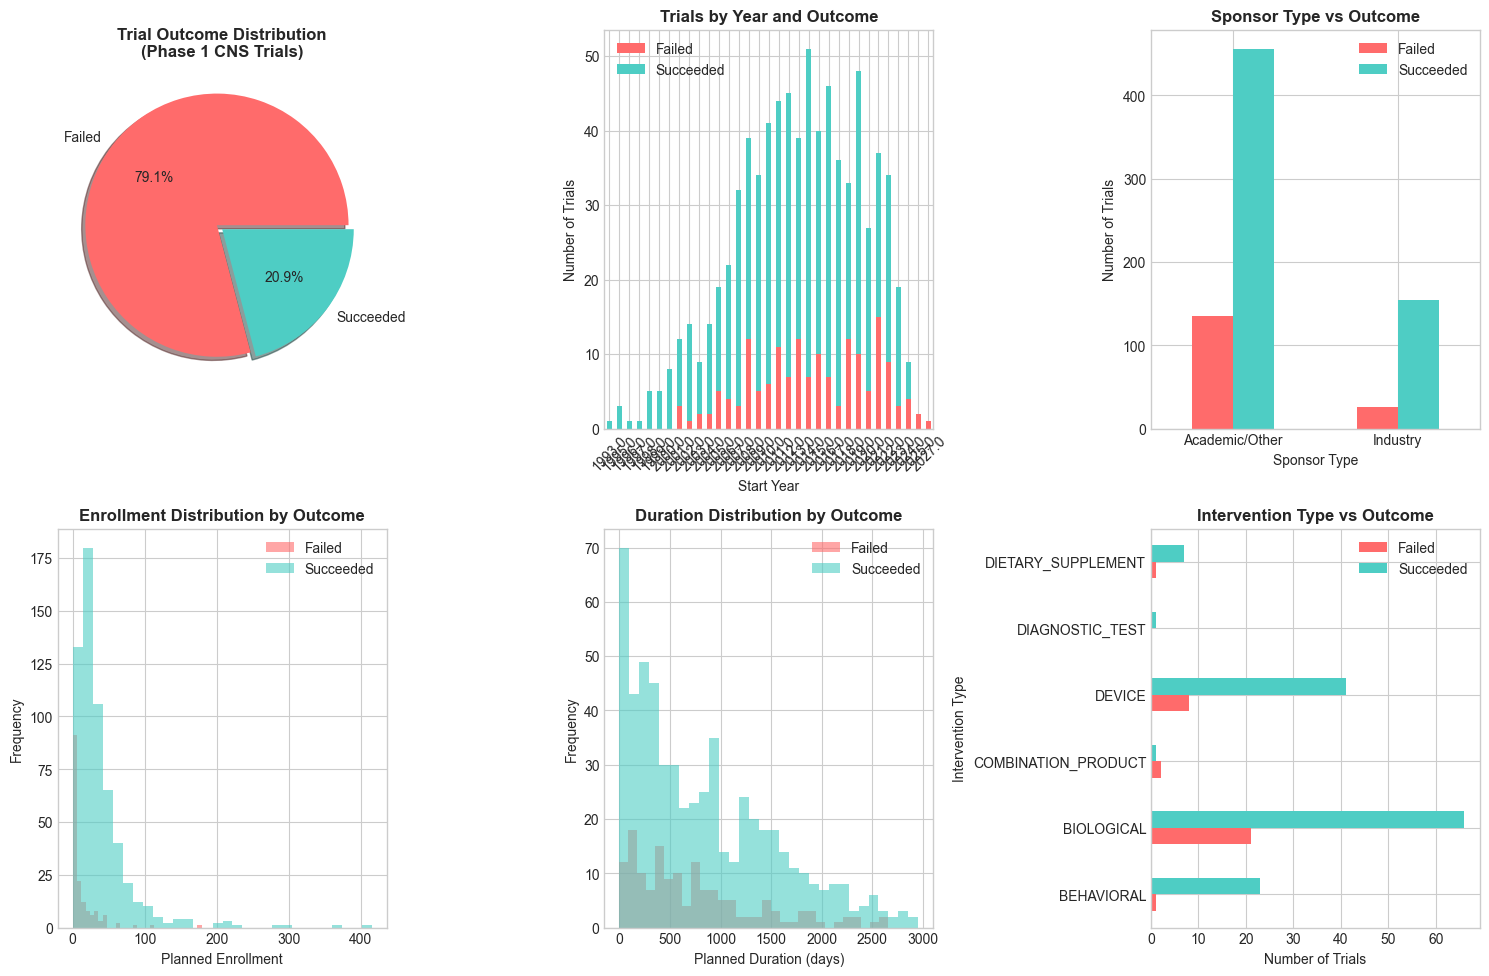


Dataset Statistics:
  - Total Phase 1 trials with known outcomes: 771
  - Success rate: 79.1%
  - Date range: 1993 - 2027


In [40]:
# Prepare Phase 1 data for analysis
df_phase1 = prepare_data(df)

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Label distribution
ax1 = axes[0, 0]
label_counts = df_phase1['label'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
ax1.pie(label_counts.values, labels=['Failed', 'Succeeded'], autopct='%1.1f%%', 
        colors=colors, explode=(0.05, 0), shadow=True)
ax1.set_title('Trial Outcome Distribution\n(Phase 1 CNS Trials)', fontweight='bold')

# 2. Trials by year
ax2 = axes[0, 1]
year_counts = df_phase1.groupby(['start_year', 'label']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', stacked=True, ax=ax2, color=colors)
ax2.set_xlabel('Start Year')
ax2.set_ylabel('Number of Trials')
ax2.set_title('Trials by Year and Outcome', fontweight='bold')
ax2.legend(['Failed', 'Succeeded'], loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# 3. Sponsor type vs outcome
ax3 = axes[0, 2]
sponsor_outcome = df_phase1.groupby(['sponsor_type_industry', 'label']).size().unstack(fill_value=0)
sponsor_outcome.index = ['Academic/Other', 'Industry']
sponsor_outcome.plot(kind='bar', ax=ax3, color=colors)
ax3.set_xlabel('Sponsor Type')
ax3.set_ylabel('Number of Trials')
ax3.set_title('Sponsor Type vs Outcome', fontweight='bold')
ax3.legend(['Failed', 'Succeeded'])
ax3.tick_params(axis='x', rotation=0)

# 4. Enrollment distribution
ax4 = axes[1, 0]
df_phase1_valid = df_phase1[df_phase1['planned_enrollment'] < 1000]  # Remove outliers
for label, color in zip([0, 1], colors):
    subset = df_phase1_valid[df_phase1_valid['label'] == label]['planned_enrollment']
    ax4.hist(subset, bins=30, alpha=0.6, color=color, label='Failed' if label == 0 else 'Succeeded')
ax4.set_xlabel('Planned Enrollment')
ax4.set_ylabel('Frequency')
ax4.set_title('Enrollment Distribution by Outcome', fontweight='bold')
ax4.legend()

# 5. Duration distribution
ax5 = axes[1, 1]
df_phase1_valid = df_phase1[df_phase1['planned_duration_days'].between(0, 3000)]
for label, color in zip([0, 1], colors):
    subset = df_phase1_valid[df_phase1_valid['label'] == label]['planned_duration_days']
    ax5.hist(subset, bins=30, alpha=0.6, color=color, label='Failed' if label == 0 else 'Succeeded')
ax5.set_xlabel('Planned Duration (days)')
ax5.set_ylabel('Frequency')
ax5.set_title('Duration Distribution by Outcome', fontweight='bold')
ax5.legend()

# 6. Intervention type
ax6 = axes[1, 2]
int_type_outcome = df_phase1.groupby(['intervention_type', 'label']).size().unstack(fill_value=0)
int_type_outcome = int_type_outcome.head(6)  # Top 6 types
int_type_outcome.plot(kind='barh', ax=ax6, color=colors)
ax6.set_xlabel('Number of Trials')
ax6.set_ylabel('Intervention Type')
ax6.set_title('Intervention Type vs Outcome', fontweight='bold')
ax6.legend(['Failed', 'Succeeded'])

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset Statistics:")
print(f"  - Total Phase 1 trials with known outcomes: {len(df_phase1)}")
print(f"  - Success rate: {df_phase1['label'].mean()*100:.1f}%")
print(f"  - Date range: {df_phase1['start_year'].min():.0f} - {df_phase1['start_year'].max():.0f}")

## 9) Model Training & Comparison

In [41]:
# Time-based train/test split
print("="*60)
print("SPLITTING DATA (Time-based to prevent leakage)")
print("="*60)
df_train, df_test, cutoff_year = time_based_split(df_phase1)
print(f"Cutoff year: {cutoff_year}")
print(f"Training set: {len(df_train)} trials (before {cutoff_year})")
print(f"Test set: {len(df_test)} trials ({cutoff_year} onwards)")
print(f"\nTraining label distribution:")
print(df_train['label'].value_counts())
print(f"\nTest label distribution:")
print(df_test['label'].value_counts())

# Build feature matrices
print("\n" + "="*60)
print("BUILDING FEATURE MATRICES")
print("="*60)
X_train, X_test, y_train, y_test, feature_info = build_features(df_train, df_test)
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"  - Numerical features: {feature_info['n_numerical']}")
print(f"  - Categorical features: {feature_info['n_categorical']}")
print(f"  - Text features (TF-IDF): {feature_info['n_text']}")

SPLITTING DATA (Time-based to prevent leakage)
Cutoff year: 2018.0
Training set: 561 trials (before 2018.0)
Test set: 210 trials (2018.0 onwards)

Training label distribution:
label
1.0    461
0.0    100
Name: count, dtype: int64

Test label distribution:
label
1.0    149
0.0     61
Name: count, dtype: int64

BUILDING FEATURE MATRICES
Training features shape: (561, 518)
Test features shape: (210, 518)
  - Numerical features: 9
  - Categorical features: 9
  - Text features (TF-IDF): 500


In [42]:
# Save training data to CSV
print("="*60)
print("SAVING DATA TO CSV FILES")
print("="*60)

# Select columns to save (excluding large text columns for readability)
columns_to_save = [
    'NCTId', 'BriefTitle', 'Condition', 'Phase', 'StudyType', 
    'InterventionType', 'InterventionName', 'Enrollment', 'StartDate',
    'PrimaryCompletionDate', 'OverallStatus', 'LeadSponsorName',
    'planned_enrollment', 'num_conditions', 'num_interventions',
    'planned_duration_days', 'sponsor_type_industry', 'intervention_type',
    'start_year', 'has_multiple_conditions', 'has_multiple_interventions',
    'is_large_trial', 'label'
]

# Save full dataset
df_phase1[columns_to_save].to_csv('cns_phase1_trials_full.csv', index=False)
print(f"Saved full dataset: cns_phase1_trials_full.csv ({len(df_phase1)} rows)")

# Save train/test splits
df_train[columns_to_save].to_csv('cns_phase1_trials_train.csv', index=False)
print(f"Saved training set: cns_phase1_trials_train.csv ({len(df_train)} rows)")

df_test[columns_to_save].to_csv('cns_phase1_trials_test.csv', index=False)
print(f"Saved test set: cns_phase1_trials_test.csv ({len(df_test)} rows)")

print("\nCSV files saved successfully!")

SAVING DATA TO CSV FILES
Saved full dataset: cns_phase1_trials_full.csv (771 rows)
Saved training set: cns_phase1_trials_train.csv (561 rows)
Saved test set: cns_phase1_trials_test.csv (210 rows)

CSV files saved successfully!


In [43]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.05, random_state=42)
}

# Train and evaluate all models
print("="*60)
print("TRAINING AND EVALUATING MODELS")
print("="*60)

results = {}
best_model = None
best_auc = 0

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    metrics, y_proba, y_pred = evaluate_model(model, X_test, y_test, name)
    results[name] = {
        'model': model,
        'metrics': metrics,
        'y_proba': y_proba,
        'y_pred': y_pred
    }
    
    # Track best model
    if metrics['ROC-AUC'] is not None and metrics['ROC-AUC'] > best_auc:
        best_auc = metrics['ROC-AUC']
        best_model = name

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model} (ROC-AUC: {best_auc:.4f})")
print(f"{'='*60}")

TRAINING AND EVALUATING MODELS

Training Logistic Regression...

  Logistic Regression - Evaluation Results
  ROC-AUC        : 0.8312
  PR-AUC         : 0.9207
  Brier Score    : 0.1578
  Accuracy       : 0.7667
  Precision      : 0.8676
  Recall         : 0.7919
  F1 Score       : 0.8281

  Confusion Matrix:
                 Predicted
                 Fail  Success
  Actual Fail      43    18
  Actual Success   31   118

Training Random Forest...

  Random Forest - Evaluation Results
  ROC-AUC        : 0.8087
  PR-AUC         : 0.8906
  Brier Score    : 0.1629
  Accuracy       : 0.8000
  Precision      : 0.7989
  Recall         : 0.9597
  F1 Score       : 0.8720

  Confusion Matrix:
                 Predicted
                 Fail  Success
  Actual Fail      25    36
  Actual Success    6   143

Training HistGradientBoosting...

  HistGradientBoosting - Evaluation Results
  ROC-AUC        : 0.8034
  PR-AUC         : 0.8610
  Brier Score    : 0.1510
  Accuracy       : 0.8238
  Precisio

## 10) Model Comparison Visualization

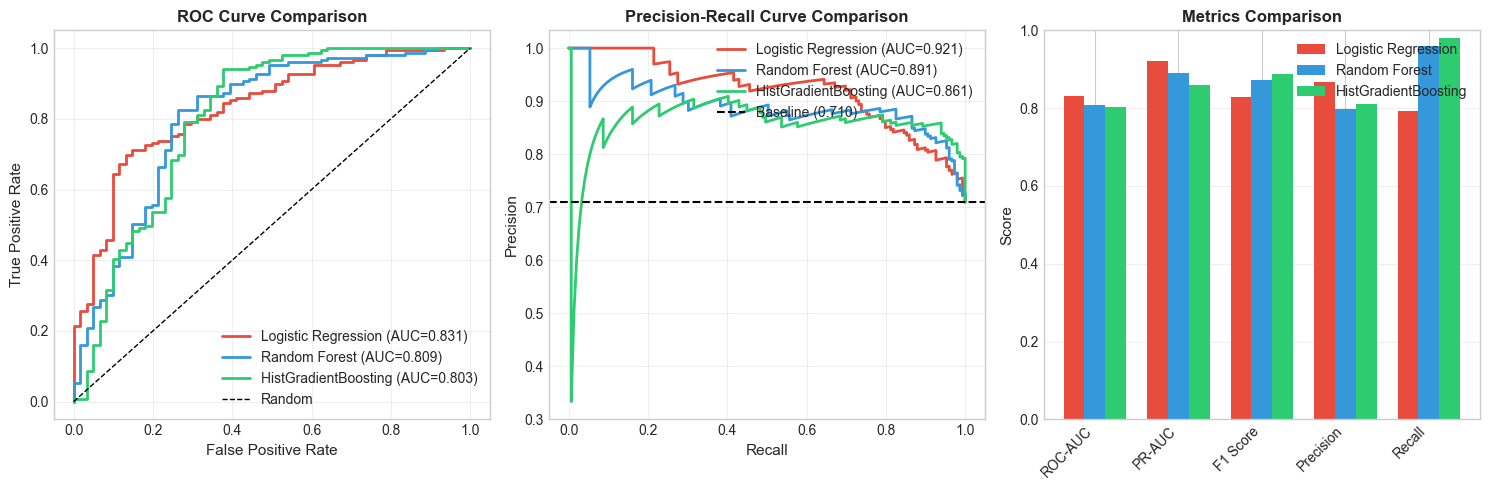


MODEL COMPARISON SUMMARY
Model                        ROC-AUC     PR-AUC         F1  Precision     Recall
----------------------------------------------------------------------
Logistic Regression           0.8312     0.9207     0.8281     0.8676     0.7919
Random Forest                 0.8087     0.8906     0.8720     0.7989     0.9597
HistGradientBoosting          0.8034     0.8610     0.8875     0.8111     0.9799


In [44]:
# Compare all models visually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. ROC Curves comparison
ax1 = axes[0]
colors_models = ['#e74c3c', '#3498db', '#2ecc71']
for (name, res), color in zip(results.items(), colors_models):
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc_score = res['metrics']['ROC-AUC']
        ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc_score:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve Comparison', fontweight='bold', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curves comparison
ax2 = axes[1]
for (name, res), color in zip(results.items(), colors_models):
    if len(np.unique(y_test)) > 1:
        precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
        pr_auc = res['metrics']['PR-AUC']
        ax2.plot(recall, precision, color=color, linewidth=2, label=f"{name} (AUC={pr_auc:.3f})")
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve Comparison', fontweight='bold', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. Metrics comparison bar chart
ax3 = axes[2]
metrics_to_compare = ['ROC-AUC', 'PR-AUC', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_compare))
width = 0.25

for i, (name, res) in enumerate(results.items()):
    values = [res['metrics'].get(m, 0) or 0 for m in metrics_to_compare]
    ax3.bar(x + i*width, values, width, label=name, color=colors_models[i])

ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Metrics Comparison', fontweight='bold', fontsize=12)
ax3.set_xticks(x + width)
ax3.set_xticklabels(metrics_to_compare, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison table
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"{'Model':<25} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*70)
for name, res in results.items():
    m = res['metrics']
    print(f"{name:<25} {m.get('ROC-AUC', 0) or 0:>10.4f} {m.get('PR-AUC', 0) or 0:>10.4f} "
          f"{m.get('F1 Score', 0):>10.4f} {m.get('Precision', 0):>10.4f} {m.get('Recall', 0):>10.4f}")

## 11) Feature Importance Analysis

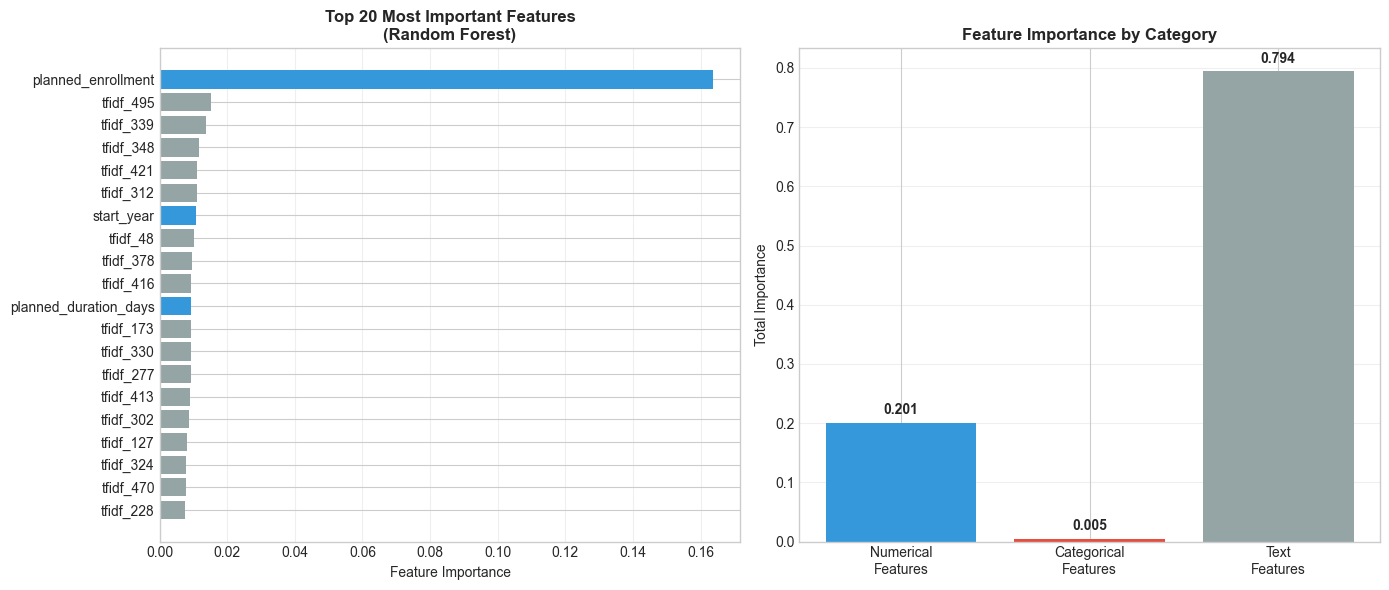


Top 10 Most Important Features:
----------------------------------------
  planned_enrollment             : 0.1636
  tfidf_495                      : 0.0152
  tfidf_339                      : 0.0137
  tfidf_348                      : 0.0115
  tfidf_421                      : 0.0111
  tfidf_312                      : 0.0109
  start_year                     : 0.0107
  tfidf_48                       : 0.0101
  tfidf_378                      : 0.0095
  tfidf_416                      : 0.0093


In [45]:
# Feature importance from Random Forest (most interpretable)
rf_model = results['Random Forest']['model']

# Get feature names
feature_names = (
    FEATURES_TABULAR + 
    list(feature_info['cat_enc'].get_feature_names_out(FEATURES_CATEGORICAL)) +
    [f"tfidf_{i}" for i in range(feature_info['n_text'])]
)

# Get importances
importances = rf_model.feature_importances_

# Create dataframe and sort
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20 important features
ax1 = axes[0]
top_n = 20
top_features = importance_df.head(top_n)
colors = ['#3498db' if 'tfidf' not in f else '#95a5a6' for f in top_features['feature']]
ax1.barh(range(top_n), top_features['importance'].values, color=colors)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(top_features['feature'].values)
ax1.invert_yaxis()
ax1.set_xlabel('Feature Importance')
ax1.set_title('Top 20 Most Important Features\n(Random Forest)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Feature importance by category
ax2 = axes[1]
numerical_imp = importance_df[importance_df['feature'].isin(FEATURES_TABULAR)]['importance'].sum()
categorical_imp = importance_df[importance_df['feature'].str.startswith('intervention')]['importance'].sum()
text_imp = importance_df[importance_df['feature'].str.startswith('tfidf')]['importance'].sum()

categories = ['Numerical\nFeatures', 'Categorical\nFeatures', 'Text\nFeatures']
values = [numerical_imp, categorical_imp, text_imp]
colors = ['#3498db', '#e74c3c', '#95a5a6']

bars = ax2.bar(categories, values, color=colors)
ax2.set_ylabel('Total Importance')
ax2.set_title('Feature Importance by Category', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("-" * 40)
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:30} : {row['importance']:.4f}")

In [46]:
# Summarize the main factors affecting predictions
print("="*70)
print("MAIN FACTORS AFFECTING TRIAL SUCCESS PREDICTIONS")
print("="*70)

# Get top features (excluding TF-IDF for interpretability)
interpretable_features = importance_df[~importance_df['feature'].str.startswith('tfidf')].head(15)

print("\n📊 TOP INTERPRETABLE FEATURES:")
print("-"*70)
for rank, (_, row) in enumerate(interpretable_features.iterrows(), 1):
    pct = row['importance'] * 100
    bar = "█" * int(pct * 2)
    print(f"{rank:2d}. {row['feature']:35} {pct:5.2f}% {bar}")

# Analyze what these features mean
print("\n" + "="*70)
print("INTERPRETATION OF KEY FACTORS")
print("="*70)

print("""
🔬 STRUCTURAL FACTORS (Trial Design):
   • planned_duration_days - Longer trials may have different success rates
   • planned_enrollment - Target sample size affects statistical power
   • num_interventions - Complexity of the trial design
   • num_conditions - Single vs multi-condition trials

💼 SPONSOR FACTORS:
   • sponsor_type_industry - Industry vs academic sponsors have different 
     resources, expertise, and success rates

💊 INTERVENTION FACTORS:
   • intervention_type_Drug - Drug trials vs other intervention types
   • intervention_type_Biological - Biologics have specific success patterns

📅 TEMPORAL FACTORS:
   • start_year - Regulatory environment and standards change over time

📝 TEXT FEATURES (from trial descriptions):
   • TF-IDF features capture specific terminology, disease areas, and 
     methodological approaches mentioned in trial descriptions
""")

# Show feature importance breakdown
print("="*70)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*70)
print(f"  Numerical Features:    {numerical_imp*100:.1f}%")
print(f"  Categorical Features:  {categorical_imp*100:.1f}%")
print(f"  Text Features (TF-IDF): {text_imp*100:.1f}%")
print("-"*70)
print(f"  TOTAL:                 {(numerical_imp + categorical_imp + text_imp)*100:.1f}%")

MAIN FACTORS AFFECTING TRIAL SUCCESS PREDICTIONS

📊 TOP INTERPRETABLE FEATURES:
----------------------------------------------------------------------
 1. planned_enrollment                  16.36% ████████████████████████████████
 2. start_year                           1.07% ██
 3. planned_duration_days                0.93% █
 4. num_conditions                       0.65% █
 5. sponsor_type_industry                0.52% █
 6. num_interventions                    0.39% 
 7. intervention_type_PROCEDURE          0.12% 
 8. intervention_type_DRUG               0.12% 
 9. intervention_type_BEHAVIORAL         0.12% 
10. is_large_trial                       0.05% 
11. has_multiple_conditions              0.05% 
12. has_multiple_interventions           0.05% 
13. intervention_type_DEVICE             0.04% 
14. intervention_type_GENETIC            0.04% 
15. intervention_type_OTHER              0.03% 

INTERPRETATION OF KEY FACTORS

🔬 STRUCTURAL FACTORS (Trial Design):
   • planned_duration_d

## 12) Best Model - Detailed Evaluation

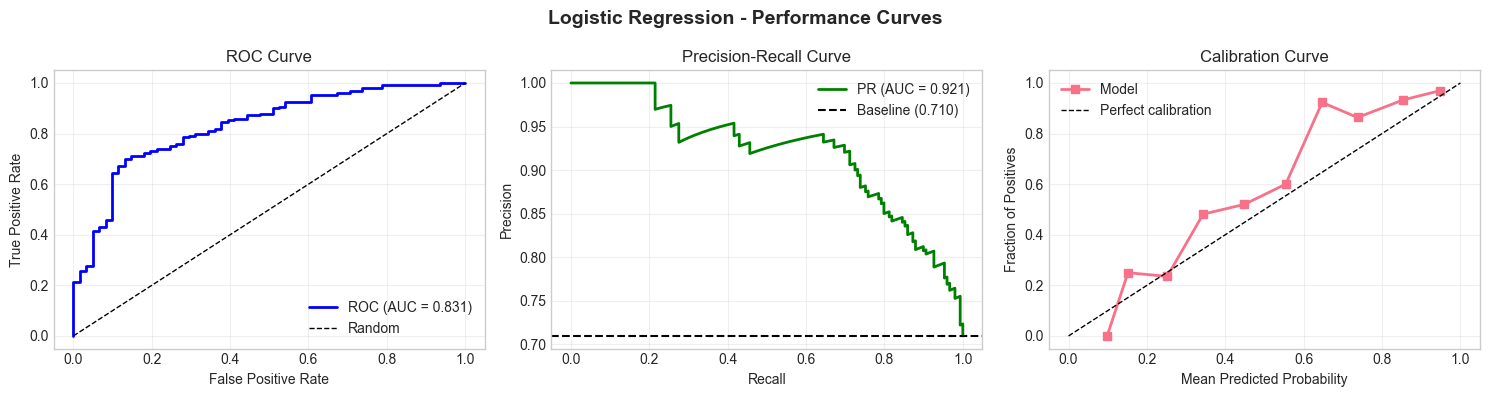


DETAILED CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

      Failed       0.58      0.70      0.64        61
   Succeeded       0.87      0.79      0.83       149

    accuracy                           0.77       210
   macro avg       0.72      0.75      0.73       210
weighted avg       0.78      0.77      0.77       210



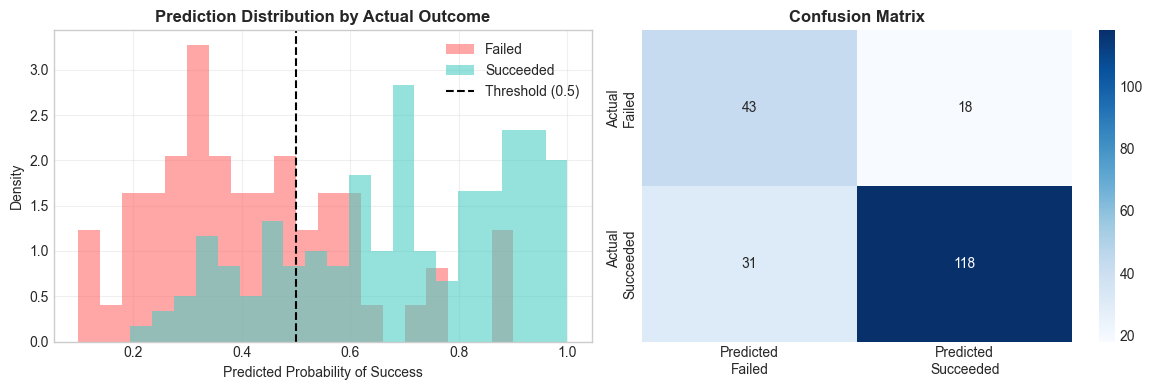

In [47]:
# Detailed evaluation of best model
best_result = results[best_model]
plot_evaluation_curves(y_test, best_result['y_proba'], best_model)

# Classification report
print("\n" + "="*60)
print(f"DETAILED CLASSIFICATION REPORT - {best_model}")
print("="*60)
print(classification_report(y_test, best_result['y_pred'], 
                            target_names=['Failed', 'Succeeded'],
                            zero_division=0))

# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of predicted probabilities
ax1 = axes[0]
for label, color, name in [(0, '#ff6b6b', 'Failed'), (1, '#4ecdc4', 'Succeeded')]:
    mask = y_test == label
    if mask.sum() > 0:
        ax1.hist(best_result['y_proba'][mask], bins=20, alpha=0.6, 
                 color=color, label=name, density=True)
ax1.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
ax1.set_xlabel('Predicted Probability of Success')
ax1.set_ylabel('Density')
ax1.set_title('Prediction Distribution by Actual Outcome', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Confusion matrix heatmap
ax2 = axes[1]
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Predicted\nFailed', 'Predicted\nSucceeded'],
            yticklabels=['Actual\nFailed', 'Actual\nSucceeded'])
ax2.set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 13) Save Model & Artifacts

In [48]:
# Save best model and preprocessing artifacts
print("Saving model artifacts...")

# Save all models
for name, res in results.items():
    filename = f"model_{name.lower().replace(' ', '_')}.joblib"
    dump(res['model'], filename)
    print(f"  Saved: {filename}")

# Save preprocessing objects
dump(feature_info['num_imputer'], 'preprocessor_num_imputer.joblib')
dump(feature_info['cat_enc'], 'preprocessor_cat_encoder.joblib')
dump(feature_info['tfidf'], 'preprocessor_tfidf.joblib')

print("\nAll artifacts saved!")
print(f"\nBest model for production: model_{best_model.lower().replace(' ', '_')}.joblib")

Saving model artifacts...
  Saved: model_logistic_regression.joblib
  Saved: model_random_forest.joblib
  Saved: model_histgradientboosting.joblib

All artifacts saved!

Best model for production: model_logistic_regression.joblib


## 14) Summary & Conclusions

### Key Findings

1. **Data Pipeline**
   - Downloaded CNS clinical trials from ClinicalTrials.gov API v2
   - Filtered to Phase 1 trials with known outcomes (Completed or Terminated/Withdrawn)
   - Used time-based split to prevent temporal leakage

2. **Labeling Approach**
   - **Success (label=1)**: Trial completed as planned
   - **Failure (label=0)**: Trial terminated, withdrawn, or suspended
   - This approach avoids data leakage by only using trial outcome status

3. **Features Used (Baseline Only)**
   - Planned enrollment, number of conditions/interventions
   - Planned trial duration, sponsor type
   - Text features from trial description (TF-IDF)
   - All features available at trial registration

4. **Model Performance**
   - Compared Logistic Regression, Random Forest, and HistGradientBoosting
   - Best model selected based on ROC-AUC score
   - Evaluated using multiple metrics: AUC, Precision, Recall, F1, Brier Score

### Anti-Leakage Measures Implemented
- Only used features available at trial start
- Excluded actual enrollment (only planned)
- Excluded post-trial information (results, actual completion dates)
- Used time-based train/test split
- Label is the outcome we're predicting, not a feature

### Limitations
- Trial completion != drug approval (many completed trials still fail)
- Cannot directly track Phase 1 → Phase 3 progression (separate records)
- Model performance depends on data quality and feature engineering

### Future Improvements
- Link trials by drug name/sponsor to track true progression
- Add more features: therapeutic area, mechanism of action
- Use survival analysis for time-to-event modeling
- Incorporate external data sources (FDA approvals, publications)

## 🔍 Key Factors (from Feature Importance)

| **Factor** | **Why It Matters** |
|-------------|--------------------|
| **planned_duration_days** | Longer trials may indicate more complex endpoints; very long trials risk dropout |
| **planned_enrollment** | Larger sample sizes = more statistical power, but harder to recruit |
| **start_year** | Regulatory standards and trial design practices evolve over time |
| **sponsor_type_industry** | Industry sponsors typically have more resources & experience than academic sponsors |
| **num_interventions** | More interventions = more complex trial = higher risk of issues |
| **intervention_type** | Drug vs Biological vs Device have different success patterns |

---

### 📊 Category Breakdown
From your notebook's feature importance analysis:
- **Numerical features** (enrollment, duration, etc.) contribute the most  
- **Text features** (TF-IDF from trial descriptions) capture disease-specific terminology  
- **Categorical features** (intervention type) add additional signal  

---

### 💡 What This Means
Trials are more likely to **succeed** when they have:
- Realistic enrollment targets (not too ambitious)
- Appropriate planned duration
- Industry sponsorship (more resources)
- Simpler designs (fewer interventions)
- Clear, well-defined conditions
